Hierarchical Clustering
Silhouette Score: 0.114
Cluster Sizes:
0    4384
1     616
Name: count, dtype: int64


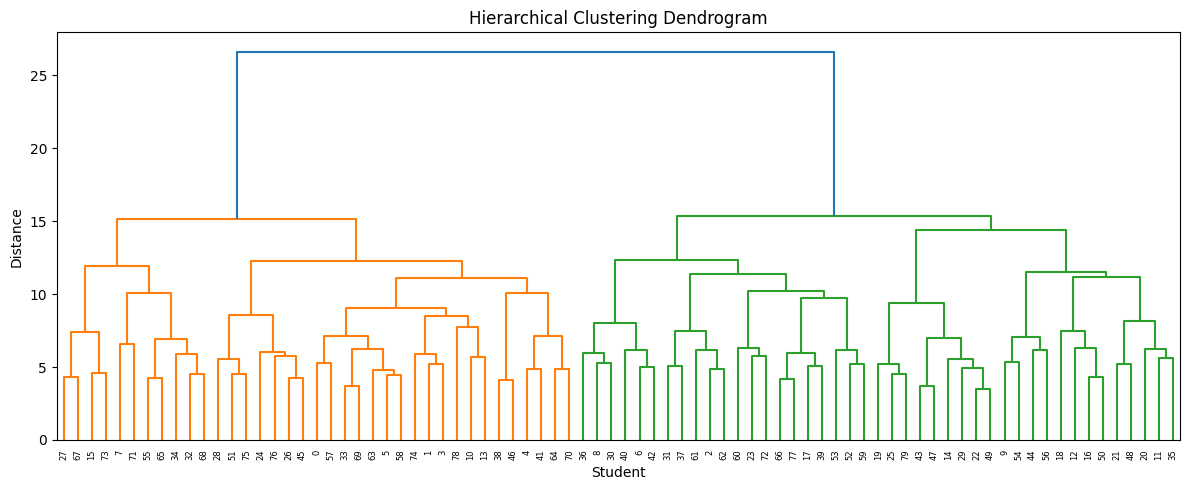

Hierarchical Clustering completed successfully.


In [1]:
# Hierarchical.py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

RANDOM_STATE = 42

NUMERIC_COLS = [
    "CGPA", "AttendancePercent", "Internships", "Projects", "Workshops",
    "Certifications", "Publications", "AptitudeTestScore",
    "SoftSkillsRating", "CodingTestScore", "MockInterviewScore"
]

CATEGORICAL_COLS = [
    "Gender", "City", "CollegeTier", "Stream", "Specialisation",
    "Hostel", "HistoryOfBacklogs", "ExtraCurricular"
]

df = pd.read_csv("placement_predict_50k_adjusted (1).csv")

imputer = SimpleImputer(strategy="median")

num_df = pd.DataFrame(
    imputer.fit_transform(df[NUMERIC_COLS]),
    columns=NUMERIC_COLS
)

cat_df = pd.get_dummies(df[CATEGORICAL_COLS], drop_first=True)

feature_df = pd.concat([num_df, cat_df], axis=1)

scaler = StandardScaler()
X = scaler.fit_transform(feature_df)

np.random.seed(RANDOM_STATE)

sample_idx = np.random.choice(
    len(X),
    5000,
    replace=False
)

X_sample = X[sample_idx]

model = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward"
)

labels = model.fit_predict(X_sample)

score = silhouette_score(
    X_sample,
    labels
)

print("Hierarchical Clustering")
print("Silhouette Score:", round(score, 3))
print("Cluster Sizes:")
print(pd.Series(labels).value_counts().sort_index())

plt.figure(figsize=(12, 5))

dendro_sample = X_sample[
    np.random.choice(
        len(X_sample),
        80,
        replace=False
    )
]

Z = linkage(
    dendro_sample,
    method="ward"
)

dendrogram(Z)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Student")
plt.ylabel("Distance")
plt.tight_layout()

plt.savefig("hierarchical_dendrogram.png")
plt.show()

print("Hierarchical Clustering completed successfully.")